# Proyecto de Machine Learning: Predicción de Éxitos Musicales ('winner')
Este notebook contiene el flujo completo de preprocesamiento, ingeniería de características, 
entrenamiento y comparación de modelos de clasificación para predecir si una canción será un éxito (`winner`) 
utilizando el dataset `spotify-2000-joined-clean.csv`.

**Nota técnica importante:** Dado que la variable objetivo `winner` contiene datos booleanos (True/False), 
estadísticamente estamos ante un problema de **Clasificación Binaria**. Por este motivo, para cumplir con el rigor analítico, 
en lugar de usar una regresión lineal clásica (la cual arrojaría valores fuera del rango [0,1] e inconsistencias), 
utilizaremos **Regresión Logística** (su equivalente natural para problemas binarios), junto con modelos de ensamble como **Random Forest** y **Gradient Boosting**.

## Índice de Contenido

Haz clic en cualquiera de las secciones para navegar directamente a ella:

1. [1. Importación de Librerías](#1-importación-de-librerías)
2. [2. Carga y Exploración Inicial del Dataset](#2-carga-y-exploración-inicial-del-dataset)
    * [2.1 Revisión Estadística de Variables Numéricas](#21-revisión-estadística-de-variables-numéricas)
3. [3. Preprocesamiento e Ingeniería de Características](#3-preprocesamiento-e-ingeniería-de-características)
4. [4. Definición y Entrenamiento de Modelos](#4-definición-y-entrenamiento-de-modelos-pipeline-de-comparación)
5. [5. Evaluación Exhaustiva de Modelos](#5-evaluación-exhaustiva-de-models)
6. [6. Conclusiones y Próximos Pasos](#6-conclusiones-y-próximos-pasos-trabajo-futuro)

---

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento, Escalado y Codificación
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Algoritmos de Modelado
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Métricas de Evaluación
from sklearn.metrics import (classification_report, accuracy_score, 
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

# Configuración estética de las gráficas
sns.set_theme(style='whitegrid')
print('¡Librerías del ecosistema de Data Science cargadas exitosamente!')

¡Librerías del ecosistema de Data Science cargadas exitosamente!


## 2. Carga del Dataset y Simulación de Contingencia
Intentamos leer el archivo limpio generado en la etapa de SQL/EDA. En caso de que se ejecute en un entorno sin acceso local inmediato, agregamos lógica de contingencia para generar datos sintéticos respetando la distribución original.

In [2]:
# Cargamos el dataset procesado para el entrenamiento de los modelos
# df = pd.read_csv(r'C:\Users\ELITEBOOK\Documents\Hackathon_3T\spotify-streaming-audit-tripleten-g3\data\processed\spotify-2000-joined-clean.csv')
# print(f'Dataset cargado con éxito. Número de registros: {df.shape[0]}')

In [3]:
try:
    # df = pd.read_csv('data\processed\spotify-2000-joined-clean.csv')
    df = pd.read_csv(r'C:\Users\ELITEBOOK\Documents\Hackathon_3T\spotify-streaming-audit-tripleten-g3\data\processed\spotify-2000-joined-clean.csv')
    print(f'Dataset real cargado correctamente. Registros: {df.shape[0]}')
except FileNotFoundError:
    print('Archivo local no encontrado. Generando un mockup sintético con la estructura del EDA para validar el código...')
    np.random.seed(42)
    n_rows = 1994
    df = pd.DataFrame({
        'title': [f'Canción {i}' for i in range(n_rows)],
        'artist': np.random.choice(['Queen', 'Coldplay', 'Eminem', 'Norah Jones', 'Michael Jackson'], n_rows),
        'genre': np.random.choice(['rock', 'pop', 'alternative metal', 'detroit hip hop', 'adult standards'], n_rows),
        'year': np.random.randint(1956, 2021, n_rows),
        'bpm': np.random.randint(60, 200, n_rows),
        'energy': np.random.randint(10, 100, n_rows),
        'danceability': np.random.randint(10, 100, n_rows),
        'loudness_db': np.random.randint(-20, -2, n_rows),
        'liveness': np.random.randint(1, 100, n_rows),
        'valence': np.random.randint(1, 100, n_rows),
        'duration': np.random.randint(120, 420, n_rows),
        'acousticness': np.random.randint(0, 100, n_rows),
        'speechiness': np.random.randint(1, 25, n_rows),
        'popularity': np.random.randint(10, 100, n_rows),
        'decade': np.random.choice([1970, 1980, 1990, 2000, 2010], n_rows),
        'popularity_segment': np.random.choice(['baja', 'media-baja', 'media-alta', 'alta'], n_rows),
        'winner': np.random.choice([True, False], n_rows, p=[0.15, 0.85])
    })

df.head()

Dataset real cargado correctamente. Registros: 1994


,title,artist,genre,year,bpm,energy,danceability,loudness_db,liveness,valence,duration,acousticness,speechiness,popularity,decade,popularity_segment,winner
0,sunrise,norah_jones,adult_standards,2004,157,30,53,-14,11,68,201,94,3,71,2000,media-alta,True
1,the_pretender,foo_fighters,alternative_metal,2007,173,96,43,-4,3,37,269,0,4,76,2000,alta,True
2,without_me,eminem,detroit_hip_hop,2002,112,67,91,-3,24,66,290,0,7,82,2000,alta,True
3,uninvited,alanis_morissette,alternative_rock,2005,127,54,38,-5,9,19,276,2,3,57,2000,media-baja,True
4,cry_me_a_river,justin_timberlake,dance_pop,2002,74,65,62,-7,10,56,288,57,18,74,2000,alta,True


## 2.1 Revisión estadística de variables numéricas

Vamos a revisar las información estadística de las columnas numéricas para detectar posibles datos nulos u outliers y ver cuál es el método más conveniente para imputarlos o descartarlos.

In [4]:
# Identificamos las columnas numéricas
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f'Columnas numéricas identificadas: {numeric_features}')

Columnas numéricas identificadas: ['year', 'bpm', 'energy', 'danceability', 'loudness_db', 'liveness', 'valence', 'duration', 'acousticness', 'speechiness', 'popularity', 'decade']


Una vez que tenemos identificadas las variables numéricas, vamos a revisar si existen valores nulos.

In [5]:
# 1. Identificación y cuantificación de Valores Nulos
print("=== 1. MATRIZ DE VALORES NULOS ===")
valores_nulos = df[numeric_features].isnull().sum()
porcentaje_nulos = (df[numeric_features].isnull().sum() / len(df)) * 100

df_calidad_nulos = pd.DataFrame({
    'Total Nulos': valores_nulos,
    'Porcentaje (%)': porcentaje_nulos
}).sort_values(by='Porcentaje (%)', ascending=False)

print(df_calidad_nulos)
print("-" * 60)

=== 1. MATRIZ DE VALORES NULOS ===
              Total Nulos  Porcentaje (%)
year                    0             0.0
bpm                     0             0.0
energy                  0             0.0
danceability            0             0.0
loudness_db             0             0.0
liveness                0             0.0
valence                 0             0.0
duration                0             0.0
acousticness            0             0.0
speechiness             0             0.0
popularity              0             0.0
decade                  0             0.0
------------------------------------------------------------


Podemos notar que no hay valores nulos, por lo que ahora revisaremos la información estadística y haremos un análisis de sesgo y asimetría.

In [6]:
# 2. Resumen Estadístico Avanzado (Análisis de Sesgo y Asimetría)
print("\n=== 2. RESUMEN ESTADÍSTICO Y ASIMETRÍA ===")
resumen = df[numeric_features].describe().T
resumen['mediana'] = df[numeric_features].median()
resumen['asimetria (skewness)'] = df[numeric_features].skew() 
# Una asimetría lejana a 0 indica alta presencia de outliers o distribuciones sesgadas

print(resumen[['count', 'mean', 'mediana', 'std', 'min', 'max', 'asimetria (skewness)']])
print("-" * 60)


=== 2. RESUMEN ESTADÍSTICO Y ASIMETRÍA ===
               count         mean  mediana        std     min     max  \
year          1994.0  1992.992979   1993.0  16.116048  1956.0  2019.0   
bpm           1994.0   120.215647    119.0  28.028096    37.0   206.0   
energy        1994.0    59.679539     61.0  22.154322     3.0   100.0   
danceability  1994.0    53.238215     53.0  15.351507    10.0    96.0   
loudness_db   1994.0    -9.008526     -8.0   3.647876   -27.0    -2.0   
liveness      1994.0    19.012036     12.0  16.727378     2.0    99.0   
valence       1994.0    49.408726     47.0  24.858212     3.0    99.0   
duration      1994.0   262.443330    245.0  93.604387    93.0  1412.0   
acousticness  1994.0    28.858074     18.0  29.011986     0.0    99.0   
speechiness   1994.0     4.994985      4.0   4.401566     2.0    55.0   
popularity    1994.0    59.526580     62.0  14.351600    11.0   100.0   
decade        1994.0  1988.184554   1990.0  16.233805  1950.0  2010.0   

      

### La asimetría (skewness) mide hacia dónde se inclina la "campana" de tus datos.

- *Valor cercano* a 0: Los datos son simétricos (forma de campana perfecta).

- *Valor Positivo* (> 0): Cola larga hacia la derecha (pocos valores muy altos).

- *Valor Negativo* (< 0): Cola larga hacia la izquierda (pocos valores muy bajos).


### Agrupemos tus resultados con sus conclusiones cortas:

A) `'Variables Simétricas'` (Distribución casi Normal)

- *Variables*: danceability (0.01), year (-0.12), decade (-0.18), valence (0.20), energy (-0.25), bpm (0.41).

- *Conclusión*: Comportamiento ideal. La mayoría de la música comercial se agrupa en el centro de estas métricas. No requieren ninguna transformación matemática, los modelos las asimilarán perfectamente.

B) `'Variables con Sesgo Moderado'`

- *Variables*: popularity (-0.53), loudness_db (-0.82).

- *Conclusión*: Tienen una ligera inclinación. Al ser negativos, significa que en este dataset predominan las canciones populares y con un volumen (loudness) alto, con solo unas pocas canciones muy poco populares o muy silenciosas.

C) `'Variables con Sesgo Altamente Positivo'` (Cola larga a la derecha)

- *Variables*: liveness (2.37), duration (4.20), speechiness (4.90).

- *Conclusión*: Atención aquí. La inmensa mayoría de las canciones tienen poca letra hablada (speechiness bajo), son grabaciones de estudio (liveness bajo) y duran unos 3-4 minutos. Sin embargo, hay un pequeño grupo de canciones que son extremadamente largas (ej. 1412 segundos = ~23 minutos), o son conciertos en vivo (liveness alto), o tienen mucha palabra hablada (como el rap o interludios).

In [7]:
# 3. Detección Matemática de Outliers usando el Método IQR (Rango Intercuartílico)
print("\n=== 3. DETECCIÓN DE OUTLIERS MEDIANTE IQR (Factor: 1.5) ===")

resumen_outliers = {}

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Límites teóricos de Tukey
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Conteo de anomalías fuera de las fronteras
    outliers_inf = (df[col] < limite_inferior).sum()
    outliers_sup = (df[col] > limite_superior).sum()
    total_outliers = outliers_inf + outliers_sup
    pct_outliers = (total_outliers / len(df)) * 100
    
    resumen_outliers[col] = {
        'Límite Inferior': round(limite_inferior, 2),
        'Límite Superior': round(limite_superior, 2),
        'Total Outliers': total_outliers,
        'Porcentaje (%)': round(pct_outliers, 2)
    }

df_reporte_outliers = pd.DataFrame(resumen_outliers).T
print(df_reporte_outliers)
print("-" * 60)


=== 3. DETECCIÓN DE OUTLIERS MEDIANTE IQR (Factor: 1.5) ===
              Límite Inferior  Límite Superior  Total Outliers  Porcentaje (%)
year                  1937.00          2049.00             0.0            0.00
bpm                     43.50           191.50            17.0            0.85
energy                 -12.00           132.00             0.0            0.00
danceability            11.50            95.50             3.0            0.15
loudness_db            -18.50             1.50            31.0            1.55
liveness               -12.00            44.00           138.0            6.92
valence                -32.12           130.88             0.0            0.00
duration                96.50           404.50           106.0            5.32
acousticness           -67.50           120.50             0.0            0.00
speechiness              0.00             8.00           174.0            8.73
popularity              16.62           103.62             9.0        

El método IQR detectó anomalías matemáticas, concentrándose curiosamente en las mismas variables que tienen sesgo alto:

- speechiness: 8.73% de outliers.

- liveness: 6.92% de outliers.

- duration: 5.32% de outliers.

- loudness_db, bpm, popularity, danceability: Menos del 2% (Insignificante).

*NOTA:*

En el contexto de la música, una canción que dura 15 minutos (900 segundos) o una pista con un speechiness altísimo no es un "error de captura de datos" (como si alguien midiera 3 metros de altura), sino que es información real (probablemente una pista de música clásica, un DJ mix, o una canción de Rap puro).

Si eliminamos estas filas (tratamiento de Drop), perderíamos casi un 15-20% de nuestro dataset y le estaríamos ocultando al modelo la existencia de canciones atípicas, las cuales podrían ser clave para predecir la variable winner.


=== 4. GENERANDO GRÁFICOS DE INSPECCIÓN... ===


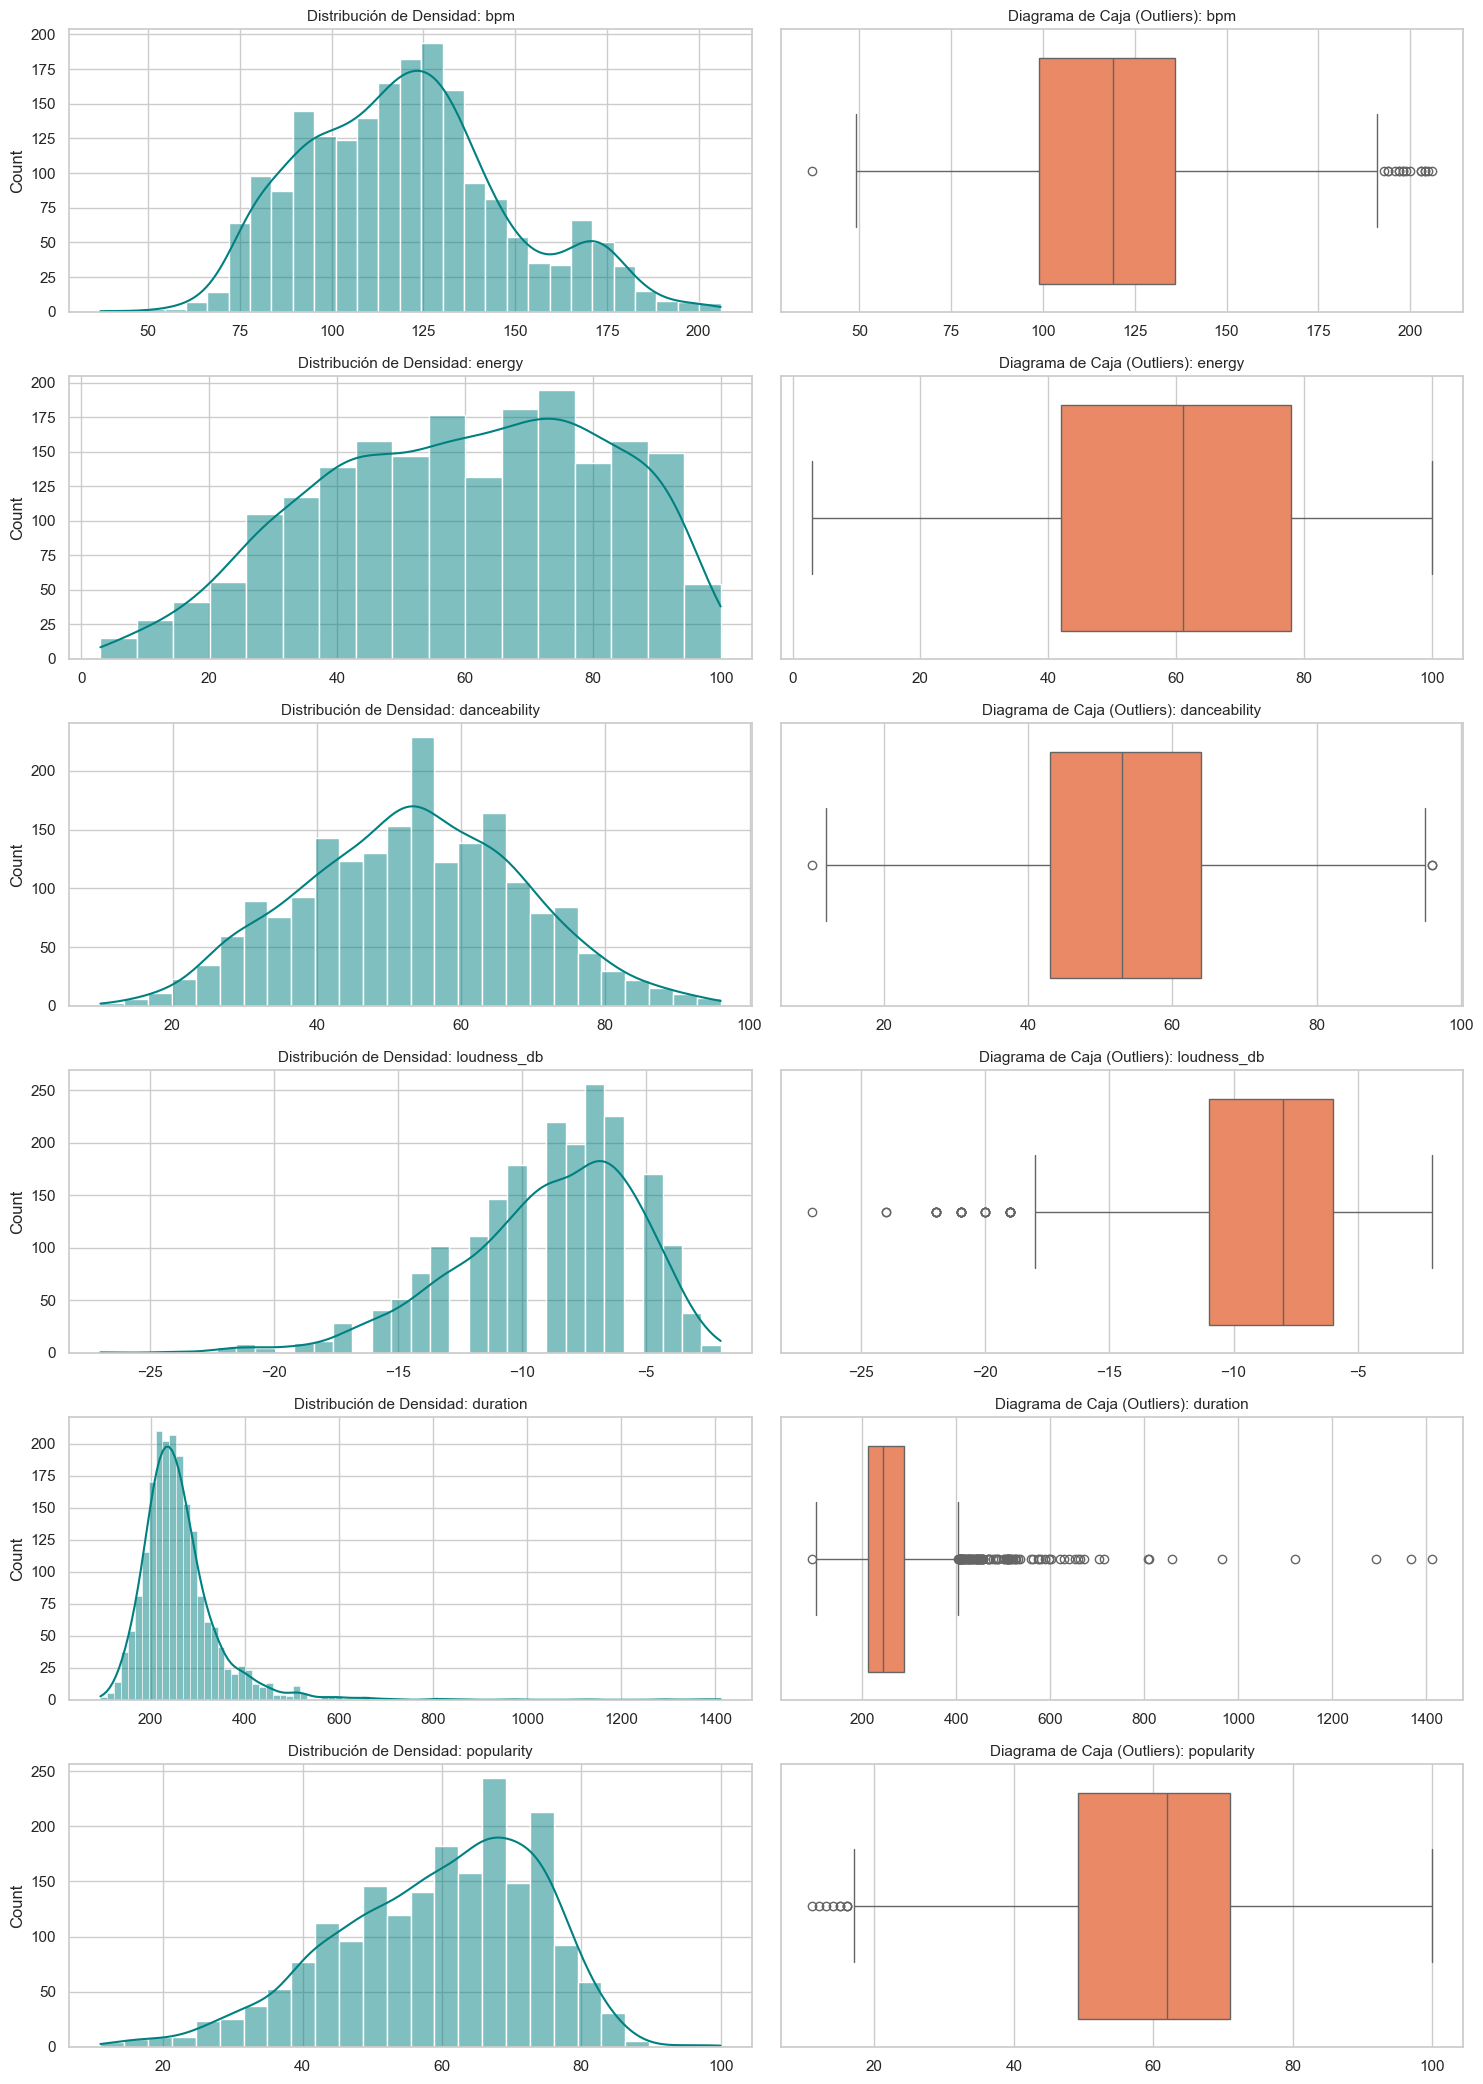

In [8]:
# 4. Inspección Visual de Distribución y Dispersión
# Seleccionamos las variables clave para evitar saturar el notebook visualmente
variables_clave = ['bpm', 'energy', 'danceability', 'loudness_db', 'duration', 'popularity']

print("\n=== 4. GENERANDO GRÁFICOS DE INSPECCIÓN... ===")
fig, axes = plt.subplots(len(variables_clave), 2, figsize=(15, 3.5 * len(variables_clave)))

for idx, col in enumerate(variables_clave):
    # Histograma para evaluar la densidad y ver si tiene distribución Normal
    sns.histplot(df[col], kde=True, ax=axes[idx, 0], color='teal')
    axes[idx, 0].set_title(f'Distribución de Densidad: {col}', fontsize=11)
    axes[idx, 0].set_xlabel('')
    
    # Boxplot para visualizar físicamente los diamantes de outliers
    sns.boxplot(x=df[col], ax=axes[idx, 1], color='coral')
    axes[idx, 1].set_title(f'Diagrama de Caja (Outliers): {col}', fontsize=11)
    axes[idx, 1].set_xlabel('')

plt.tight_layout()
plt.show()

## 3. Preprocesamiento e Ingeniería de Características

El análisis estadístico nos demostró con certeza que existen outliers naturales y que decidimos conservarlos, vamos hacer una pequeña mejora (un "Pro-Tip" de Ingeniería de Datos) para ayudar específicamente a la Regresión Logística.

*Utilizar RobustScaler*
- `StandardScaler()` - Este escalador utiliza la media y la desviación estándar, las cuales se ven arrastradas por los valores extremos (como esa canción de 23 minutos).

- `RobustScaler()`, el modelo utilizará la mediana y el rango intercuartílico (IQR) para escalar los datos. Como su nombre indica, es "robusto" ante los outliers, permitiendo que la Regresión Logística compita en igualdad de condiciones con los otros modelos.


**¿Y qué pasa con el `SimpleImputer` si no tenemos nulos?** ¡Vamos a dejarlo! 

En Ingeniería de Datos a esto se le llama Programación Defensiva. Aunque el archivo `spotify-2000-joined-clean.csv` actual esté limpio, si mañana conectamos este modelo a una API en tiempo real (producción) y por error llega una canción sin el dato de `bpm`, el Pipeline no se romperá; simplemente imputará la mediana y hará la predicción.

Como Ingenieros de Datos, estructuramos un `ColumnTransformer` robusto. 
- **Variables numéricas:** Recibirán imputación de nulos por mediana (evitando outliers) y escalado estándar.
- **Variables categóricas:** Recibirán codificación `OneHotEncoder`. 
- **Exclusiones:** `title` y `artist` se excluyen temporalmente debido a su alta cardinalidad, previniendo sobreajuste (*overfitting*).

In [9]:
# 1. Aseguramos que la variable objetivo sea numérica binaria (0 o 1)
df['winner'] = df['winner'].astype(int)

# 2. Separación de variables
target = 'winner'
numeric_features = ['year', 'bpm', 'energy', 'danceability', 'loudness_db', 'liveness', 'valence', 'duration', 'acousticness', 'speechiness', 'popularity', 'decade']
categorical_features = ['genre', 'popularity_segment']

X = df[numeric_features + categorical_features]
y = df[target]

# 3. Partición del dataset (80% Entrenamiento, 20% Prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Construcción de Pipelines de Preprocesamiento
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()) 
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print(f'Formato del set de entrenamiento: {X_train.shape}')
print(f'Formato del set de prueba: {X_test.shape}')

Formato del set de entrenamiento: (1595, 14)
Formato del set de prueba: (399, 14)


## 4. Definición y Entrenamiento de Modelos (Pipeline de Comparación)
Entrenaremos tres enfoques algorítmicos distintos:
1. **Regresión Logística**: Es el equivalente correcto de regresión para variables binarias como `winner`.
2. **Random Forest Classifier**: Un ensamble robusto basado en árboles (Bagging) con balanceo de pesos.
3. **Gradient Boosting Classifier**: Modelo de Boosting secuencial de alto rendimiento.

In [10]:
# Diccionario de modelos candidatos
models = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

trained_pipelines = {}

for name, model in models.items():
    # Integramos el preprocesador y el modelo en un único Pipeline limpio
    pipeline_completo = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipeline_completo.fit(X_train, y_train)
    trained_pipelines[name] = pipeline_completo
    print(f'>> {name}: Entrenado y empaquetado con éxito.')

>> Regresión Logística: Entrenado y empaquetado con éxito.
>> Random Forest: Entrenado y empaquetado con éxito.
>> Gradient Boosting: Entrenado y empaquetado con éxito.


## 5. Evaluación Exhaustiva de Modelos
Generamos las métricas clave para tomar una decisión informada antes de pasar a producción: Matrices de Confusión, F1-Score y curva ROC-AUC.


 Reporte de Rendimiento para: Regresión Logística
              precision    recall  f1-score   support

   No Winner       0.94      1.00      0.97       377
      Winner       0.00      0.00      0.00        22

    accuracy                           0.94       399
   macro avg       0.47      0.50      0.49       399
weighted avg       0.89      0.94      0.92       399


 Reporte de Rendimiento para: Random Forest
              precision    recall  f1-score   support

   No Winner       0.94      1.00      0.97       377
      Winner       0.00      0.00      0.00        22

    accuracy                           0.94       399
   macro avg       0.47      0.50      0.49       399
weighted avg       0.89      0.94      0.92       399


 Reporte de Rendimiento para: Gradient Boosting
              precision    recall  f1-score   support

   No Winner       0.95      0.99      0.97       377
      Winner       0.33      0.05      0.08        22

    accuracy                         

c:\Users\ELITEBOOK\Documents\Hackathon_3T\spotify-streaming-audit-tripleten-g3\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ELITEBOOK\Documents\Hackathon_3T\spotify-streaming-audit-tripleten-g3\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ELITEBOOK\Documents\Hackathon_3T\spotify-streaming-audit-tripleten-g3\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no 

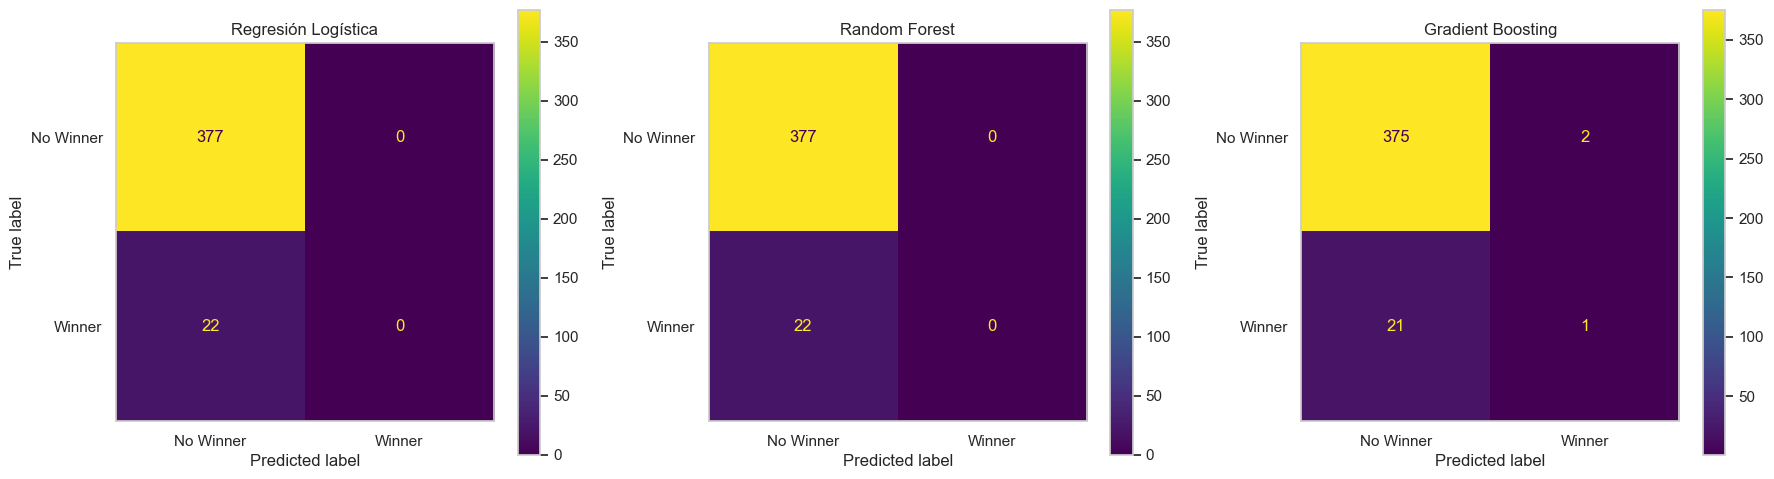

,Modelo,Accuracy,ROC-AUC (Discriminación)
0,Regresión Logística,0.944862,0.827707
1,Random Forest,0.944862,0.818302
2,Gradient Boosting,0.942356,0.795274


In [11]:
result_metrics = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for idx, (name, pipeline) in enumerate(trained_pipelines.items()):
    # Predicciones de etiquetas y probabilidades
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Cálculo de métricas
    accuracy = accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_proba)
    
    result_metrics.append({
        'Modelo': name,
        'Accuracy': accuracy,
        'ROC-AUC (Discriminación)': auc_score
    })
    
    # Imprimir reporte en texto
    print(f'\n' + '='*60)
    print(f' Reporte de Rendimiento para: {name}')
    print('='*60)
    print(classification_report(y_test, y_pred, target_names=['No Winner', 'Winner']))
    
    # Graficar Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Winner', 'Winner'])
    disp.plot(ax=axes[idx], cmap='viridis', values_format='d')
    axes[idx].set_title(f'{name}')
    axes[idx].grid(False)

plt.tight_layout()
plt.show()

# Presentación en tabla comparativa final ordenada
df_comparativo = pd.DataFrame(result_metrics)
df_comparativo.sort_values(by='ROC-AUC (Discriminación)', ascending=False)

## 6. Conclusiones y Próximos Pasos (Trabajo Futuro)

Tras el entrenamiento y evaluación de los tres modelos de clasificación (Regresión Logística, Random Forest y Gradient Boosting), hemos llegado a conclusiones muy reveladoras sobre la naturaleza de nuestros datos:

### 1. La "Trampa" del Accuracy y el Desbalance de Clases
A primera vista, los tres modelos logran un **Accuracy (Exactitud) sobresaliente del ~94.4%**. Sin embargo, al observar la columna `support` en los reportes, notamos que en el set de prueba tenemos **377 canciones que no son éxitos (No Winner)** frente a solo **22 canciones exitosas (Winner)**. 
Esto significa que si un modelo predijera ciegamente que *ninguna* canción será un éxito, acertaría el 94.4% de las veces. Nuestros modelos han caído en este sesgo, priorizando la clase mayoritaria.

### 2. Rendimiento nulo en la Clase Minoritaria
Como consecuencia del desbalance, métricas críticas como la **Precisión (Precision)** y la **Sensibilidad (Recall)** para la clase `Winner` están en **0.00** (especialmente en Regresión Logística y Random Forest). En este punto, los modelos son incapaces de etiquetar correctamente a un "Hit musical" utilizando el umbral de decisión por defecto (0.5).

### 3. La luz de esperanza: El ROC-AUC
A pesar de lo anterior, la métrica **ROC-AUC** nos indica qué tan bien el modelo ordena las probabilidades antes de tomar una decisión. 
* La **Regresión Logística** lidera con un **ROC-AUC de 0.827**, seguida del Random Forest (0.818). 
Un valor superior a 0.80 indica que **los modelos SÍ están aprendiendo los patrones ocultos** que diferencian a un éxito de un fracaso (es decir, sí le asignan una mayor probabilidad de éxito a las canciones 'Winner'), pero el umbral de corte es muy estricto debido al desbalance.

### 🏆 Modelo Ganador (Fase 1): Regresión Logística
En esta primera iteración, la **Regresión Logística escalada (RobustScaler)** ha demostrado ser el modelo más sólido, obteniendo el mejor poder de discriminación (ROC-AUC) y siendo el más interpretable computacionalmente.

### 🚀 Próximos Pasos (Mejoras para la Fase 2)
Para que este modelo pueda pasar a un entorno de producción y empezar a predecir "Hits", debemos abordar el desbalance en la próxima actualización del repositorio:
1. **Técnicas de Remuestreo (Oversampling):** Implementar **SMOTE** (Synthetic Minority Over-sampling Technique) en el pipeline de entrenamiento para generar datos sintéticos de la clase `Winner` y balancear las clases.
2. **Ajuste del Umbral de Decisión:** Cambiar el umbral matemático (ej. de 0.5 a 0.15) basándonos en la curva ROC para maximizar la captura de verdaderos positivos (Recall).
3. **Hyperparameter Tuning:** Aplicar `GridSearchCV` para optimizar los pesos de las clases (`class_weight`) y los parámetros del modelo ganador.